# AdventureWorks Internet Sales — Exploratory Data Analysis

**Data Analytics Portfolio Project | SQL → Python EDA**

---

This notebook analyses the **AdventureWorks** internet sales data (Microsoft's
sample data-warehouse). The raw tables were first cleaned in SQL and exported as
CSVs; here we load them in Python and perform a full exploratory data analysis.

We follow the standard data-analysis workflow:

1. Business understanding
2. Data loading
3. Data inspection
4. Data cleaning & preparation (star-schema join)
5. Exploratory Data Analysis (Sales overview, Customers, Products, Fulfilment)
6. Key insights
7. Conclusion & recommendations

## 1. Business Understanding

AdventureWorks is a fictional bicycle-and-accessories retailer. The internet
sales data is modelled as a **star schema**: a central fact table
(`FactInternetSales`) linked to dimension tables for date, customer and product.

Management wants to understand:

- **Overview:** How are sales trending, and are we hitting budget?
- **Customers:** Who are our best customers, and how do sales split by gender
  and city?
- **Products:** Which categories, subcategories and products sell best?
- **Fulfilment:** How quickly do we ship orders after they are placed?

## 2. Setup & Data Loading

We use the classic Python data-analysis stack: **pandas**/**numpy** for data
handling and **matplotlib**/**seaborn** for visualisation.

The exported CSVs have **no header row**, so we supply the column names (taken
from the SQL `SELECT` statements in `data/original_sql_queries.sql`). The
literal strings `NULL` and `NA` are treated as missing values.

In [3]:
# --- Core libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display & plot styling ---
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.edgecolor"] = "#cccccc"

PALETTE = "viridis"
ACCENT = "#2b6cb0"
sns.set_palette("deep")

print("Libraries loaded.")
print("pandas", pd.__version__, "| numpy", np.__version__)

Libraries loaded.
pandas 3.0.3 | numpy 2.5.1


In [4]:
# --- Load the star-schema tables ---
from pathlib import Path

DATA_DIR = Path("data")
NA = ["NULL", "NA", ""]

# Column names come from the cleaned SQL SELECT statements.
customer_cols = ["CustomerKey", "FirstName", "LastName", "FullName",
                 "Gender", "DateFirstPurchase", "CustomerCity"]
date_cols = ["DateKey", "Date", "Day", "Month", "MonthShort",
             "MonthNo", "Quarter", "Year"]
product_cols = ["ProductKey", "ProductAlternateKey", "ProductName",
                "ProductSubcategory", "ProductCategory", "ProductColor",
                "ProductSize", "ProductLine", "ProductModelName",
                "ProductDescription", "ProductStatus"]
fact_cols = ["ProductKey", "OrderDateKey", "DueDateKey", "ShipDateKey",
             "CustomerKey", "SalesOrderNumber", "SalesAmount"]

dim_customer = pd.read_csv(DATA_DIR / "DimCustomer.csv", header=None,
                           names=customer_cols, na_values=NA)
dim_date = pd.read_csv(DATA_DIR / "DimDate.csv", header=None,
                       names=date_cols, na_values=NA)
dim_product = pd.read_csv(DATA_DIR / "DimProduct.csv", header=None,
                          names=product_cols, na_values=NA)
fact_sales = pd.read_csv(DATA_DIR / "FactInternetSales.csv", header=None,
                         names=fact_cols, na_values=NA)
budget = pd.read_excel(DATA_DIR / "SalesBudget.xlsx")

print("DimCustomer     ", dim_customer.shape)
print("DimDate         ", dim_date.shape)
print("DimProduct      ", dim_product.shape)
print("FactInternetSales", fact_sales.shape)
print("SalesBudget     ", budget.shape)

DimCustomer      (18484, 7)
DimDate          (1096, 8)
DimProduct       (606, 11)
FactInternetSales (54771, 7)
SalesBudget      (18, 2)


## 3. Data Inspection

A quick look at the structure, sample rows, data types and missing values.

In [5]:
# Preview the fact table (one row per order line).
fact_sales.head()

,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,CustomerKey,SalesOrderNumber,SalesAmount
0,361,20210101,20210113,20210108,11249,SO51247,"2,294.99"
1,477,20210101,20210113,20210108,11249,SO51247,4.99
2,478,20210101,20210113,20210108,11249,SO51247,9.99
3,378,20210101,20210113,20210108,12307,SO51248,"2,443.35"
4,353,20210101,20210113,20210108,11334,SO51249,"2,319.99"


In [6]:
# Preview the product dimension.
dim_product.head()

,ProductKey,ProductAlternateKey,ProductName,ProductSubcategory,ProductCategory,ProductColor,ProductSize,ProductLine,ProductModelName,ProductDescription,ProductStatus
0,1,AR-5381,Adjustable Race,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Current
1,2,BA-8327,Bearing Ball,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Current
2,3,BE-2349,BB Ball Bearing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Current
3,4,BE-2908,Headset Ball Bearings,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Current
4,5,BL-2036,Blade,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Current


In [7]:
# Structure of the fact table.
fact_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 54771 entries, 0 to 54770
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ProductKey        54771 non-null  int64  
 1   OrderDateKey      54771 non-null  int64  
 2   DueDateKey        54771 non-null  int64  
 3   ShipDateKey       54771 non-null  int64  
 4   CustomerKey       54771 non-null  int64  
 5   SalesOrderNumber  54771 non-null  str    
 6   SalesAmount       54771 non-null  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 2.9 MB


In [8]:
# Sales amount summary statistics.
print(fact_sales["SalesAmount"].describe())

count   54,771.00
mean       299.38
std        677.40
min          2.29
25%          4.99
50%         24.99
75%         53.99
max      2,443.35
Name: SalesAmount, dtype: float64


In [9]:
# Missing values per table.
tables = {"DimCustomer": dim_customer, "DimDate": dim_date,
          "DimProduct": dim_product, "FactInternetSales": fact_sales,
          "SalesBudget": budget}
print("Missing values per table:\n")
for name, df in tables.items():
    print(f"  {name:18s} total missing = {int(df.isna().sum().sum())}")
print("\nNote: missing product attributes are expected — non-saleable "
      "components (e.g. 'Adjustable Race') have no category/colour/size.")

Missing values per table:

  DimCustomer        total missing = 0
  DimDate            total missing = 0
  DimProduct         total missing = 1624
  FactInternetSales  total missing = 0
  SalesBudget        total missing = 0

Note: missing product attributes are expected — non-saleable components (e.g. 'Adjustable Race') have no category/colour/size.


## 4. Data Cleaning & Preparation

Steps:

- Parse date columns.
- Fill missing product categories/subcategories with a clear label.
- **Join the star schema** into one analysis-ready `sales` table by linking the
  fact table to the date, customer and product dimensions.
- Engineer helper columns (order month, ship lead time).

In [10]:
# --- 4.1 Parse dates ---
dim_date["Date"] = pd.to_datetime(dim_date["Date"], errors="coerce")
dim_customer["DateFirstPurchase"] = pd.to_datetime(
    dim_customer["DateFirstPurchase"], errors="coerce")
budget["Date"] = pd.to_datetime(budget["Date"], errors="coerce")

# --- 4.2 Tidy product attributes ---
for col in ["ProductSubcategory", "ProductCategory", "ProductColor",
            "ProductLine"]:
    dim_product[col] = dim_product[col].fillna("Unknown")

print("Dates parsed and product attributes tidied.")
print("Date dimension range:", dim_date["Date"].min().date(),
      "->", dim_date["Date"].max().date())

Dates parsed and product attributes tidied.
Date dimension range: 2020-01-01 -> 2022-12-31


In [11]:
# --- 4.3 Join the star schema into one analysis table ---
date_lookup = dim_date.set_index("DateKey")["Date"]

sales = fact_sales.copy()
sales["OrderDate"] = sales["OrderDateKey"].map(date_lookup)
sales["ShipDate"] = sales["ShipDateKey"].map(date_lookup)

# Bring in date attributes (year, quarter, month) on the order date.
sales = sales.merge(
    dim_date[["DateKey", "Year", "Quarter", "Month", "MonthShort",
              "MonthNo", "Day"]],
    left_on="OrderDateKey", right_on="DateKey", how="left")

# Bring in customer and product attributes.
sales = sales.merge(dim_customer, on="CustomerKey", how="left")
sales = sales.merge(dim_product, on="ProductKey", how="left")

# --- 4.4 Helper columns ---
sales["OrderMonth"] = sales["OrderDate"].dt.to_period("M").dt.to_timestamp()
sales["ShipLeadDays"] = (sales["ShipDate"] - sales["OrderDate"]).dt.days

print("Unified sales table:", sales.shape)
print("Order date range:", sales["OrderDate"].min().date(),
      "->", sales["OrderDate"].max().date())
sales[["SalesOrderNumber", "OrderDate", "FullName", "ProductName",
       "ProductCategory", "SalesAmount"]].head()

Unified sales table: (54771, 34)
Order date range: 2021-01-01 -> 2022-01-28


,SalesOrderNumber,OrderDate,FullName,ProductName,ProductCategory,SalesAmount
0,SO51247,2021-01-01,Cindy Patel,"Mountain-200 Black, 42",Bikes,"2,294.99"
1,SO51247,2021-01-01,Cindy Patel,Water Bottle - 30 oz.,Accessories,4.99
2,SO51247,2021-01-01,Cindy Patel,Mountain Bottle Cage,Accessories,9.99
3,SO51248,2021-01-01,Brad She,"Road-250 Black, 52",Bikes,"2,443.35"
4,SO51249,2021-01-01,Nicole Brown,"Mountain-200 Silver, 38",Bikes,"2,319.99"


## 5. Exploratory Data Analysis

### 5.1 Sales Overview

In [12]:
# Headline KPIs.
total_sales   = sales["SalesAmount"].sum()
num_orders    = sales["SalesOrderNumber"].nunique()
num_lines     = len(sales)
num_customers = sales["CustomerKey"].nunique()
num_products  = sales["ProductKey"].nunique()
aov           = total_sales / num_orders

print(f"Total Sales       : ${total_sales:,.0f}")
print(f"Distinct Orders   : {num_orders:,}")
print(f"Order Lines       : {num_lines:,}")
print(f"Active Customers  : {num_customers:,}")
print(f"Products Sold     : {num_products:,}")
print(f"Avg Order Value   : ${aov:,.0f}")

Total Sales       : $16,397,245
Distinct Orders   : 22,160
Order Lines       : 54,771
Active Customers  : 17,935
Products Sold     : 102
Avg Order Value   : $740


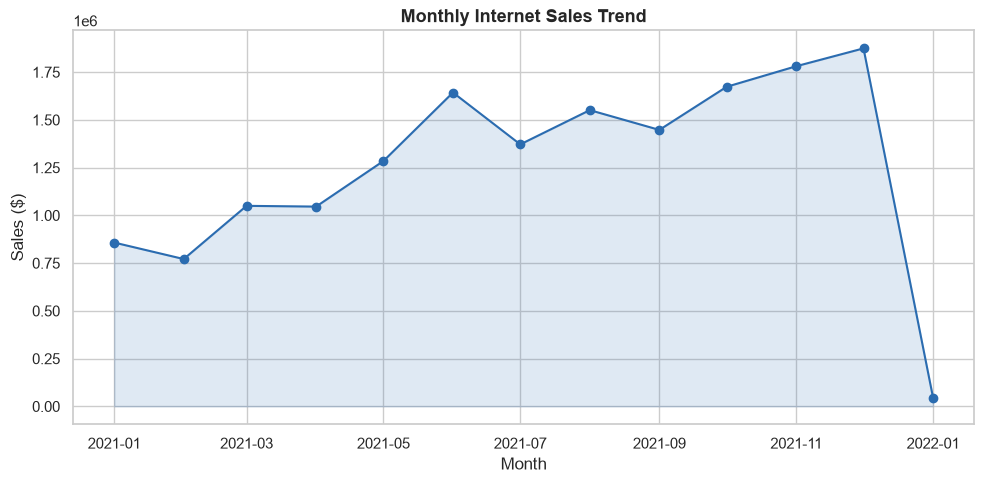

In [13]:
# Monthly sales trend.
monthly_sales = sales.groupby("OrderMonth")["SalesAmount"].sum()

fig, ax = plt.subplots()
ax.plot(monthly_sales.index, monthly_sales.values, marker="o", color=ACCENT)
ax.fill_between(monthly_sales.index, monthly_sales.values, alpha=0.15, color=ACCENT)
ax.set_title("Monthly Internet Sales Trend")
ax.set_xlabel("Month"); ax.set_ylabel("Sales ($)")
plt.tight_layout(); plt.show()

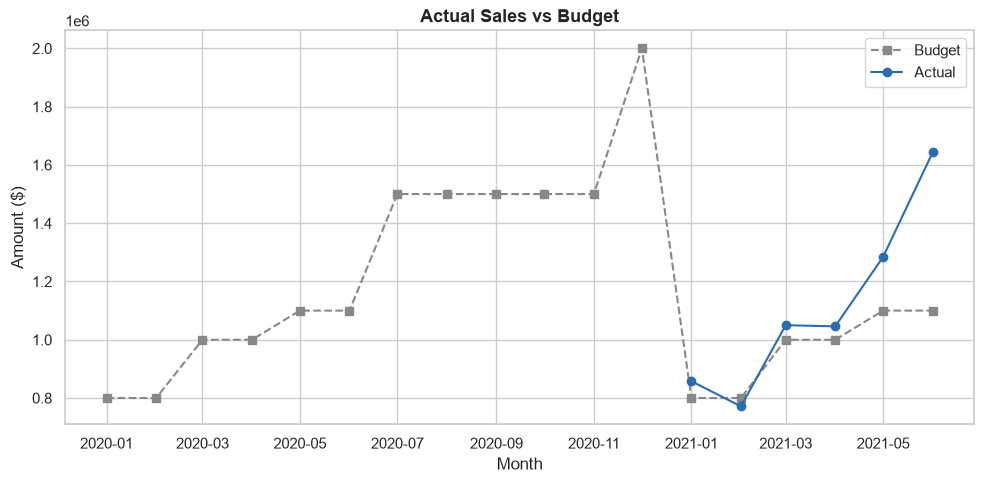

      Date  Budget       Actual   Variance  Achieved_%
2020-01-01  800000          NaN        NaN         NaN
2020-02-01  800000          NaN        NaN         NaN
2020-03-01 1000000          NaN        NaN         NaN
2020-04-01 1000000          NaN        NaN         NaN
2020-05-01 1100000          NaN        NaN         NaN
2020-06-01 1100000          NaN        NaN         NaN
2020-07-01 1500000          NaN        NaN         NaN
2020-08-01 1500000          NaN        NaN         NaN
2020-09-01 1500000          NaN        NaN         NaN
2020-10-01 1500000          NaN        NaN         NaN
2020-11-01 1500000          NaN        NaN         NaN
2020-12-01 2000000          NaN        NaN         NaN
2021-01-01  800000   857,689.91  57,689.91      107.21
2021-02-01  800000   771,348.74 -28,651.26       96.42
2021-03-01 1000000 1,049,907.39  49,907.39      104.99
2021-04-01 1000000 1,046,022.77  46,022.77      104.60
2021-05-01 1100000 1,284,592.93 184,592.93      116.78
2021-06-01

In [14]:
# Actual sales vs budget (monthly).
actual = monthly_sales.rename("Actual").reset_index()
actual.columns = ["Date", "Actual"]
compare = budget.merge(actual, on="Date", how="left").sort_values("Date")

fig, ax = plt.subplots()
ax.plot(compare["Date"], compare["Budget"], marker="s",
        label="Budget", color="#888888", linestyle="--")
ax.plot(compare["Date"], compare["Actual"], marker="o",
        label="Actual", color=ACCENT)
ax.set_title("Actual Sales vs Budget")
ax.set_xlabel("Month"); ax.set_ylabel("Amount ($)")
ax.legend()
plt.tight_layout(); plt.show()

compare["Variance"] = compare["Actual"] - compare["Budget"]
compare["Achieved_%"] = compare["Actual"] / compare["Budget"] * 100
print(compare[["Date", "Budget", "Actual", "Variance", "Achieved_%"]]
      .to_string(index=False))

C:\Users\arun_\AppData\Local\Temp\ipykernel_36300\1523404927.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_year.index.astype(int), y=by_year.values,
C:\Users\arun_\AppData\Local\Temp\ipykernel_36300\1523404927.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_quarter.index.astype(int), y=by_quarter.values,


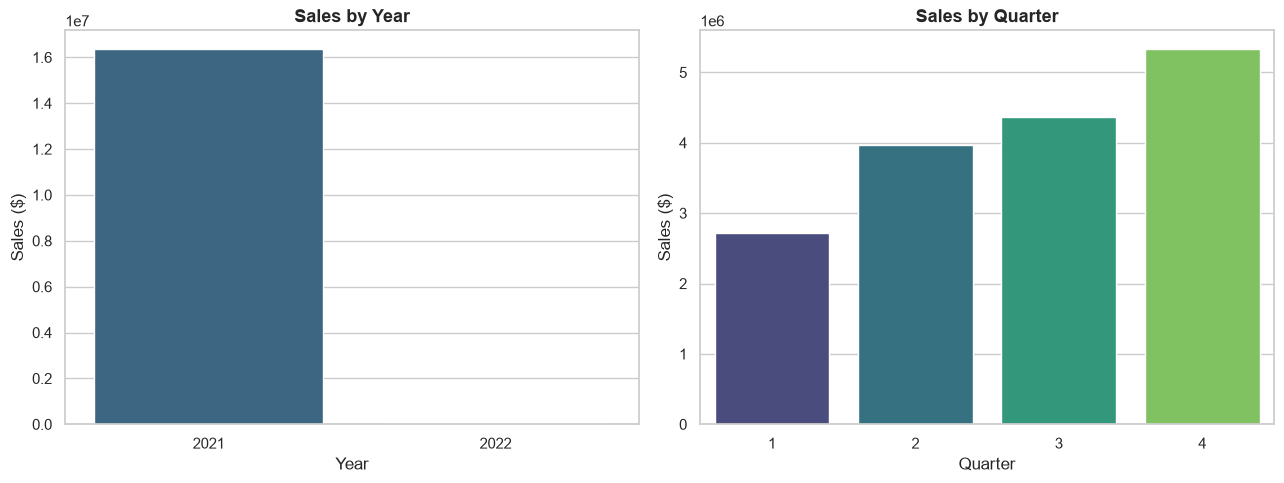

In [15]:
# Sales by year and by quarter.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

by_year = sales.groupby("Year")["SalesAmount"].sum()
sns.barplot(x=by_year.index.astype(int), y=by_year.values,
            palette=PALETTE, ax=axes[0])
axes[0].set_title("Sales by Year")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Sales ($)")

by_quarter = sales.groupby("Quarter")["SalesAmount"].sum()
sns.barplot(x=by_quarter.index.astype(int), y=by_quarter.values,
            palette=PALETTE, ax=axes[1])
axes[1].set_title("Sales by Quarter")
axes[1].set_xlabel("Quarter"); axes[1].set_ylabel("Sales ($)")

plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_36300\1708045340.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_day.index, y=by_day.values, palette="mako", ax=ax)


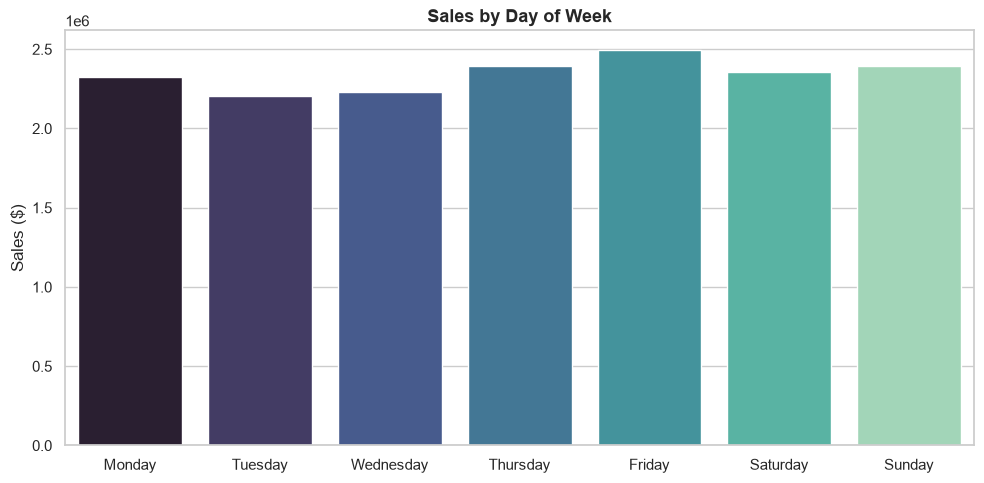

In [16]:
# Sales by day of week.
order = ["Monday", "Tuesday", "Wednesday", "Thursday",
         "Friday", "Saturday", "Sunday"]
by_day = (sales.groupby("Day")["SalesAmount"].sum()
          .reindex(order).dropna())
fig, ax = plt.subplots()
sns.barplot(x=by_day.index, y=by_day.values, palette="mako", ax=ax)
ax.set_title("Sales by Day of Week")
ax.set_xlabel(""); ax.set_ylabel("Sales ($)")
plt.tight_layout(); plt.show()

### 5.2 Sales by Customer

C:\Users\arun_\AppData\Local\Temp\ipykernel_36300\391868712.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index,


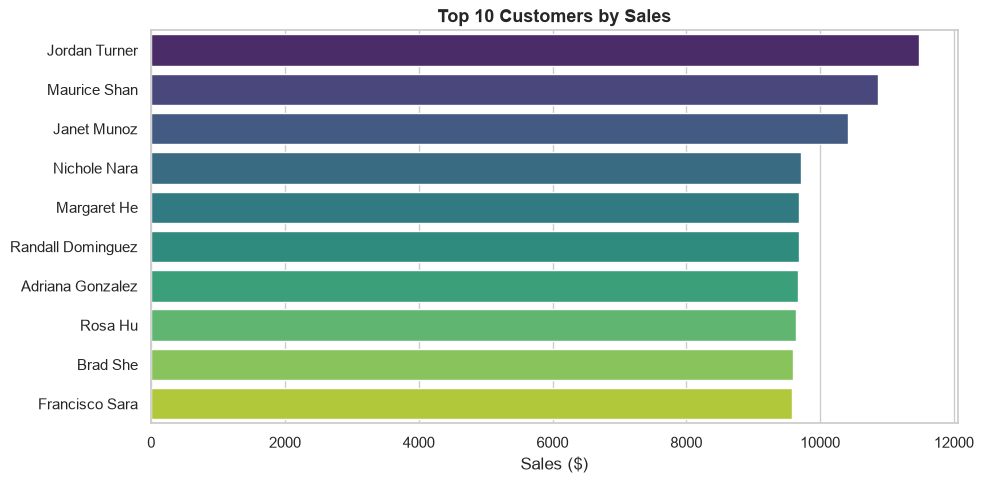

In [17]:
# Top 10 customers by sales.
top_customers = (sales.groupby("FullName")["SalesAmount"].sum()
                 .sort_values(ascending=False).head(10))
fig, ax = plt.subplots()
sns.barplot(x=top_customers.values, y=top_customers.index,
            palette=PALETTE, ax=ax)
ax.set_title("Top 10 Customers by Sales")
ax.set_xlabel("Sales ($)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_36300\3095550507.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette=PALETTE, ax=axes[1])


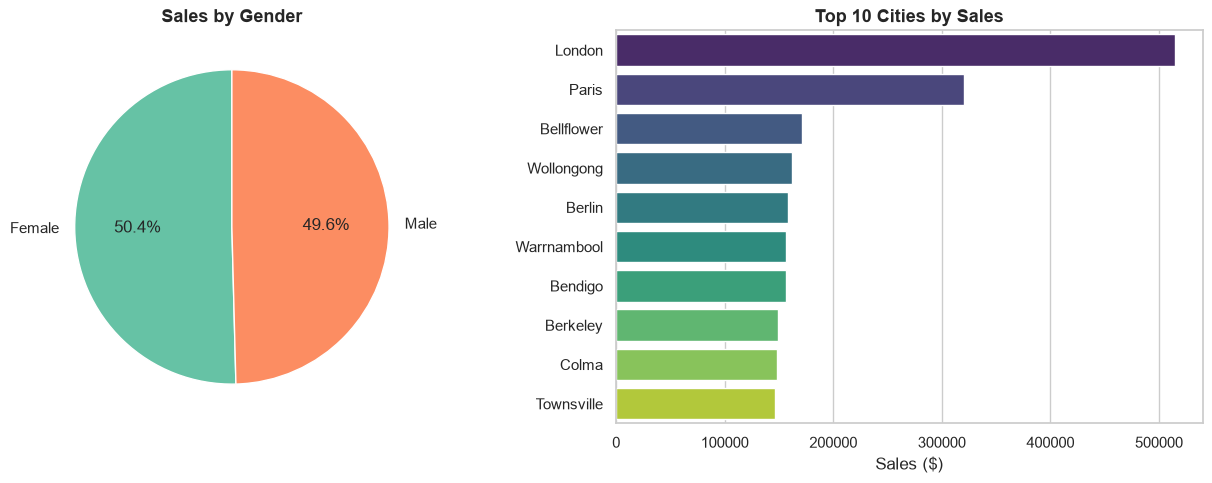

In [18]:
# Sales split by gender and top cities.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

by_gender = sales.groupby("Gender")["SalesAmount"].sum()
axes[0].pie(by_gender.values, labels=by_gender.index, autopct="%1.1f%%",
            startangle=90, colors=sns.color_palette("Set2", len(by_gender)))
axes[0].set_title("Sales by Gender")

top_cities = (sales.groupby("CustomerCity")["SalesAmount"].sum()
              .sort_values(ascending=False).head(10))
sns.barplot(x=top_cities.values, y=top_cities.index, palette=PALETTE, ax=axes[1])
axes[1].set_title("Top 10 Cities by Sales")
axes[1].set_xlabel("Sales ($)"); axes[1].set_ylabel("")

plt.tight_layout(); plt.show()

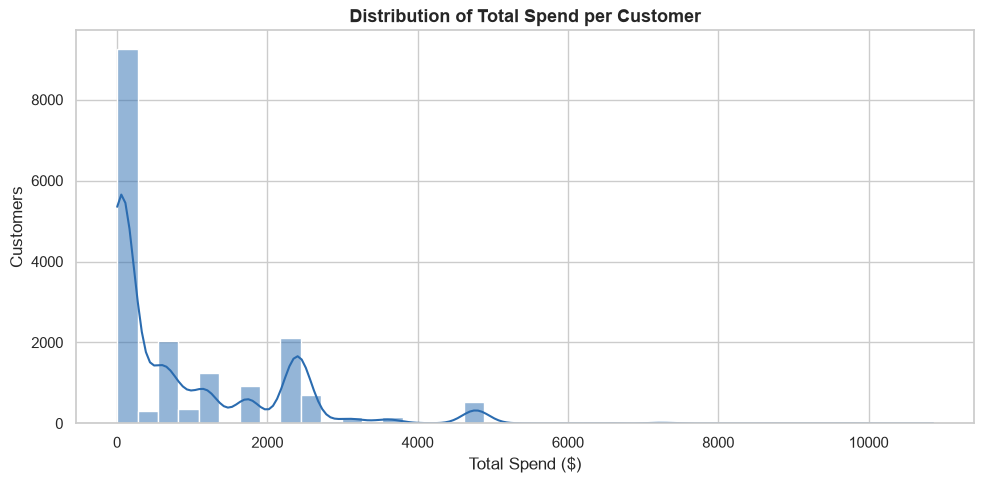

Median customer spend: $186
Mean customer spend:   $914


In [19]:
# Distribution of spend per customer.
spend = sales.groupby("CustomerKey")["SalesAmount"].sum()
fig, ax = plt.subplots()
sns.histplot(spend, bins=40, kde=True, color=ACCENT, ax=ax)
ax.set_title("Distribution of Total Spend per Customer")
ax.set_xlabel("Total Spend ($)"); ax.set_ylabel("Customers")
plt.tight_layout(); plt.show()
print(f"Median customer spend: ${spend.median():,.0f}")
print(f"Mean customer spend:   ${spend.mean():,.0f}")

### 5.3 Sales by Product

C:\Users\arun_\AppData\Local\Temp\ipykernel_36300\2562589363.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_sub.values, y=by_sub.index, palette=PALETTE, ax=axes[1])


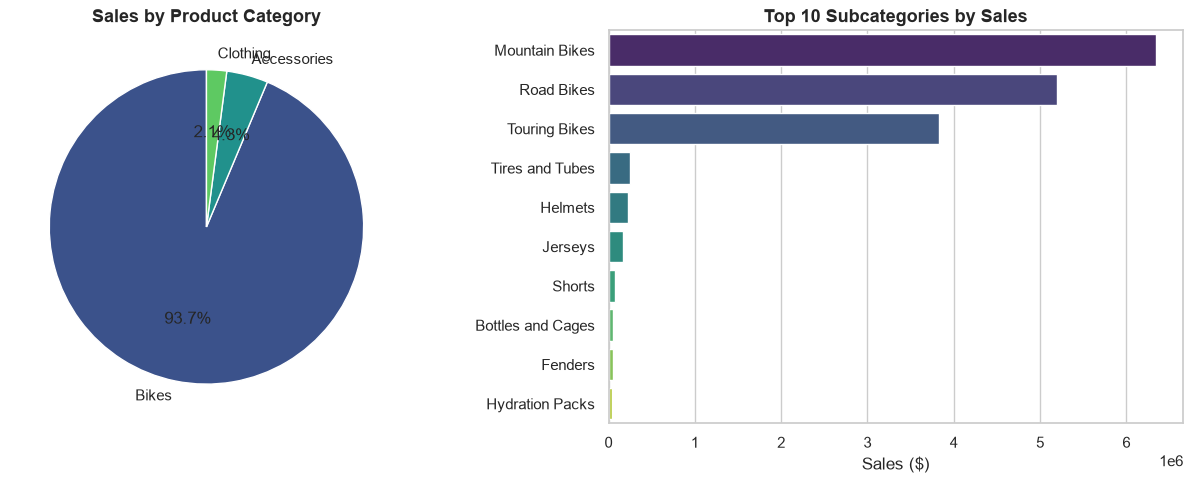

In [20]:
# Sales by product category and top subcategories.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

by_cat = sales.groupby("ProductCategory")["SalesAmount"].sum().sort_values(ascending=False)
axes[0].pie(by_cat.values, labels=by_cat.index, autopct="%1.1f%%",
            startangle=90, colors=sns.color_palette(PALETTE, len(by_cat)))
axes[0].set_title("Sales by Product Category")

by_sub = (sales.groupby("ProductSubcategory")["SalesAmount"].sum()
          .sort_values(ascending=False).head(10))
sns.barplot(x=by_sub.values, y=by_sub.index, palette=PALETTE, ax=axes[1])
axes[1].set_title("Top 10 Subcategories by Sales")
axes[1].set_xlabel("Sales ($)"); axes[1].set_ylabel("")

plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_36300\3016003155.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette=PALETTE, ax=ax)


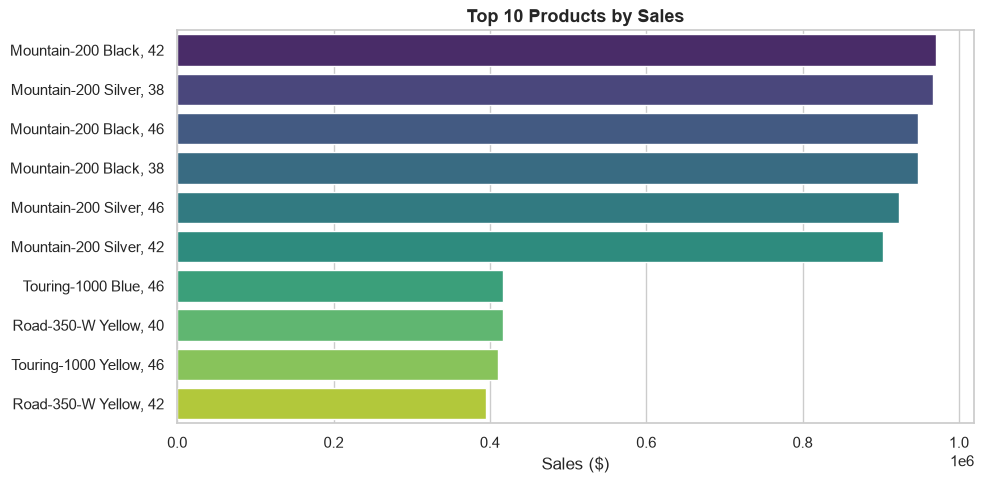

In [21]:
# Top 10 individual products by sales.
top_products = (sales.groupby("ProductName")["SalesAmount"].sum()
                .sort_values(ascending=False).head(10))
fig, ax = plt.subplots()
sns.barplot(x=top_products.values, y=top_products.index, palette=PALETTE, ax=ax)
ax.set_title("Top 10 Products by Sales")
ax.set_xlabel("Sales ($)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_36300\156436695.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_color.index, y=by_color.values, palette=PALETTE, ax=axes[0])
C:\Users\arun_\AppData\Local\Temp\ipykernel_36300\156436695.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_line.index, y=by_line.values, palette="mako", ax=axes[1])


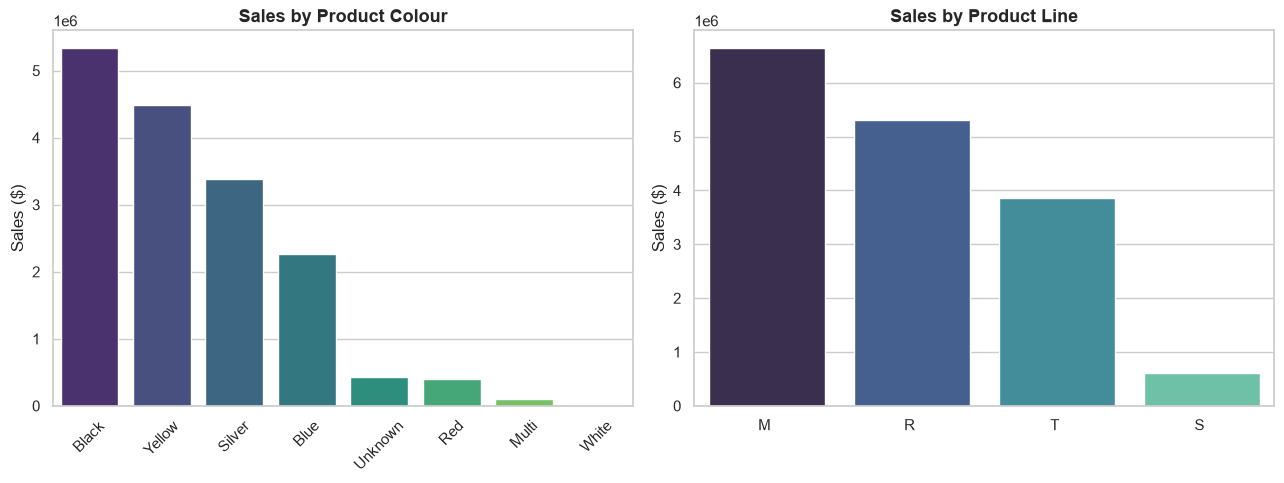

In [22]:
# Sales by product colour and product line.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

by_color = (sales.groupby("ProductColor")["SalesAmount"].sum()
            .sort_values(ascending=False).head(10))
sns.barplot(x=by_color.index, y=by_color.values, palette=PALETTE, ax=axes[0])
axes[0].set_title("Sales by Product Colour")
axes[0].set_xlabel(""); axes[0].set_ylabel("Sales ($)")
axes[0].tick_params(axis="x", rotation=45)

by_line = sales.groupby("ProductLine")["SalesAmount"].sum().sort_values(ascending=False)
sns.barplot(x=by_line.index, y=by_line.values, palette="mako", ax=axes[1])
axes[1].set_title("Sales by Product Line")
axes[1].set_xlabel(""); axes[1].set_ylabel("Sales ($)")

plt.tight_layout(); plt.show()

### 5.4 Order Fulfilment

How long between an order being placed and shipped?

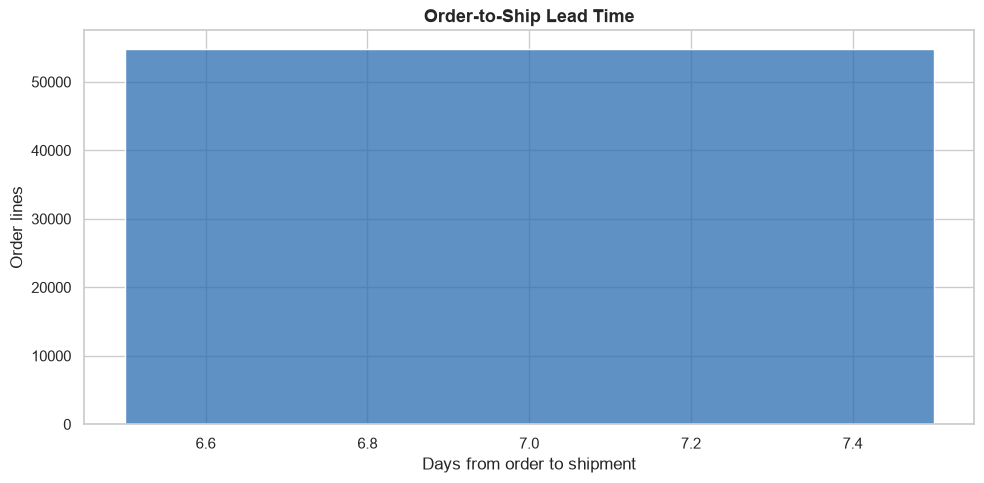

Average ship lead time: 7.0 days
Most common lead time : 7 days


In [23]:
lead = sales["ShipLeadDays"].dropna()
fig, ax = plt.subplots()
sns.histplot(lead, bins=int(lead.max() - lead.min() + 1),
             color=ACCENT, ax=ax)
ax.set_title("Order-to-Ship Lead Time")
ax.set_xlabel("Days from order to shipment"); ax.set_ylabel("Order lines")
plt.tight_layout(); plt.show()
print(f"Average ship lead time: {lead.mean():.1f} days")
print(f"Most common lead time : {int(lead.mode().iloc[0])} days")

## 6. Key Insights

> The numbers below are computed from the data so they always stay accurate.

In [24]:
best_month = monthly_sales.idxmax()
top_cat = by_cat.index[0]
top_cat_share = by_cat.iloc[0] / by_cat.sum() * 100
top_customer = top_customers.index[0]
top_product = top_products.index[0]
male_share = by_gender.get("Male", 0) / by_gender.sum() * 100
months_over_budget = int((compare["Variance"] > 0).sum())

print("KEY INSIGHTS")
print("=" * 58)
print(f"1. Total internet sales of ${total_sales:,.0f} across {num_orders:,} orders.")
print(f"2. Average order value is ${aov:,.0f}.")
print(f"3. Best sales month was {best_month:%B %Y}.")
print(f"4. '{top_cat}' is the top category ({top_cat_share:.1f}% of sales).")
print(f"5. Best-selling product: {top_product}.")
print(f"6. Top customer by spend: {top_customer}.")
print(f"7. Male vs female split: {male_share:.1f}% male.")
print(f"8. Actual sales beat budget in {months_over_budget} of {len(compare)} months.")
print(f"9. Orders ship in about {lead.mean():.1f} days on average.")

KEY INSIGHTS
1. Total internet sales of $16,397,245 across 22,160 orders.
2. Average order value is $740.
3. Best sales month was December 2021.
4. 'Bikes' is the top category (93.7% of sales).
5. Best-selling product: Mountain-200 Black, 42.
6. Top customer by spend: Jordan Turner.
7. Male vs female split: 49.6% male.
8. Actual sales beat budget in 5 of 18 months.
9. Orders ship in about 7.0 days on average.


## 7. Conclusion & Recommendations

**Conclusion.** AdventureWorks' internet channel is concentrated in a dominant
product category and shows clear seasonality, with actual sales tracking against
an explicit monthly budget.

**Recommendations.**

1. **Double down on the top category** while nurturing smaller categories
   (accessories, clothing) to reduce dependence on a single product line.
2. **Investigate months that missed budget** and align marketing spend with the
   strongest-selling months identified in the trend.
3. **Grow high-value customers** — the spend distribution is skewed, so a small
   group of customers drives a large share of revenue; a loyalty programme could
   protect them.
4. **Review fulfilment consistency** — monitor the order-to-ship lead time to
   keep the customer experience predictable.

## 8. Future Work

- Add **time-series forecasting** for sales vs budget.
- Build an **RFM / customer-segmentation** analysis on top of the spend data.
- Connect the notebook to the live SQL warehouse so it refreshes automatically.

---
*Python EDA companion to the original SQL + Power BI AdventureWorks project.*